<a href="https://colab.research.google.com/github/Satyam593-lang/Satyam593-lang/blob/main/personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin-1')


In [6]:
# 1. Dataset Overview
print("Dataset Shape:", df.shape)
print("\nKey Columns Present:")
print(df[['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Delivery Status', 'Order Status']].head())

# 2. KPI Calculations
total_orders = len(df)
late_orders = (df['Delivery Status'] == 'Late delivery').sum()
on_time_delivery_rate = ((total_orders - late_orders) / total_orders) * 100
avg_shipping_delay = (df['Days for shipping (real)'] - df['Days for shipment (scheduled)']).mean()
print("\n---LOGISTICS KPIs ---")
print(f"Total Orders Analyzed: {total_orders:,}")
print(f"On-Time Delivery Rate: {on_time_delivery_rate:.2f}%")
print(f"Late Delivery Rate: {100 - on_time_delivery_rate:.2f}%")
print(f"Average Shipping Delay: {avg_shipping_delay:.2f} days")

Dataset Shape: (180519, 53)

Key Columns Present:
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

    Delivery Status     Order Status  
0  Advance shipping         COMPLETE  
1     Late delivery          PENDING  
2  Shipping on time           CLOSED  
3  Advance shipping         COMPLETE  
4  Advance shipping  PENDING_PAYMENT  

---LOGISTICS KPIs ---
Total Orders Analyzed: 180,519
On-Time Delivery Rate: 45.17%
Late Delivery Rate: 54.83%
Average Shipping Delay: 0.57 days


In [8]:
df.columns = df.columns.str.strip()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Load your dataset
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin-1')

# Clean up column names by stripping trailing whitespace
df.columns = df.columns.str.strip()

# 2. KPI Calculations using your exact column names
total_orders = len(df)
late_orders = (df['Delivery Status'] == 'Late delivery').sum()
on_time_delivery_rate = ((total_orders - late_orders) / total_orders) * 100
avg_benefit = df['Benefit per order'].mean()
avg_sales_per_customer = df['Sales per customer'].mean()
print("\n---LOGISTICS & FINANCIAL KPIs ---")
print(f"Total Orders: {total_orders:,}")
print(f"On-Time Delivery Rate: {on_time_delivery_rate:.2f}%")
print(f"Late Delivery Rate: {100 - on_time_delivery_rate:.2f}%")
print(f"Average Profit per Order: ${avg_benefit:.2f}")
print(f"Average Sales per Customer: ${avg_sales_per_customer:.2f}\n")

# 3. Feature Selection & Preprocessing
features = ['Benefit per order', 'Sales per customer', 'Order Region', 'Order Status', 'Late_delivery_risk']
model_df = df[features].dropna().copy()

# Encode categorical variables
le_region = LabelEncoder()
le_status = LabelEncoder()

model_df['Order Region Encoded'] = le_region.fit_transform(model_df['Order Region'])
model_df['Order Status Encoded'] = le_status.fit_transform(model_df['Order Status'])

X = model_df[['Benefit per order', 'Sales per customer', 'Order Region Encoded', 'Order Status Encoded']]
y = model_df['Late_delivery_risk']

# 4. Train Predictive Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Output Results
y_pred = model.predict(X_test)
print("---PREDICTIVE MODEL PERFORMANCE ---")
print("Model Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


---LOGISTICS & FINANCIAL KPIs ---
Total Orders: 180,519
On-Time Delivery Rate: 45.17%
Late Delivery Rate: 54.83%
Average Profit per Order: $21.97
Average Sales per Customer: $183.11

---PREDICTIVE MODEL PERFORMANCE ---
Model Accuracy: 54.55 %

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.42      0.46     16307
           1       0.58      0.65      0.61     19797

    accuracy                           0.55     36104
   macro avg       0.54      0.53      0.53     36104
weighted avg       0.54      0.55      0.54     36104



/tmp/ipykernel_660/3226363462.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_660/3226363462.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_660/3226363462.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_660/3226363462.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


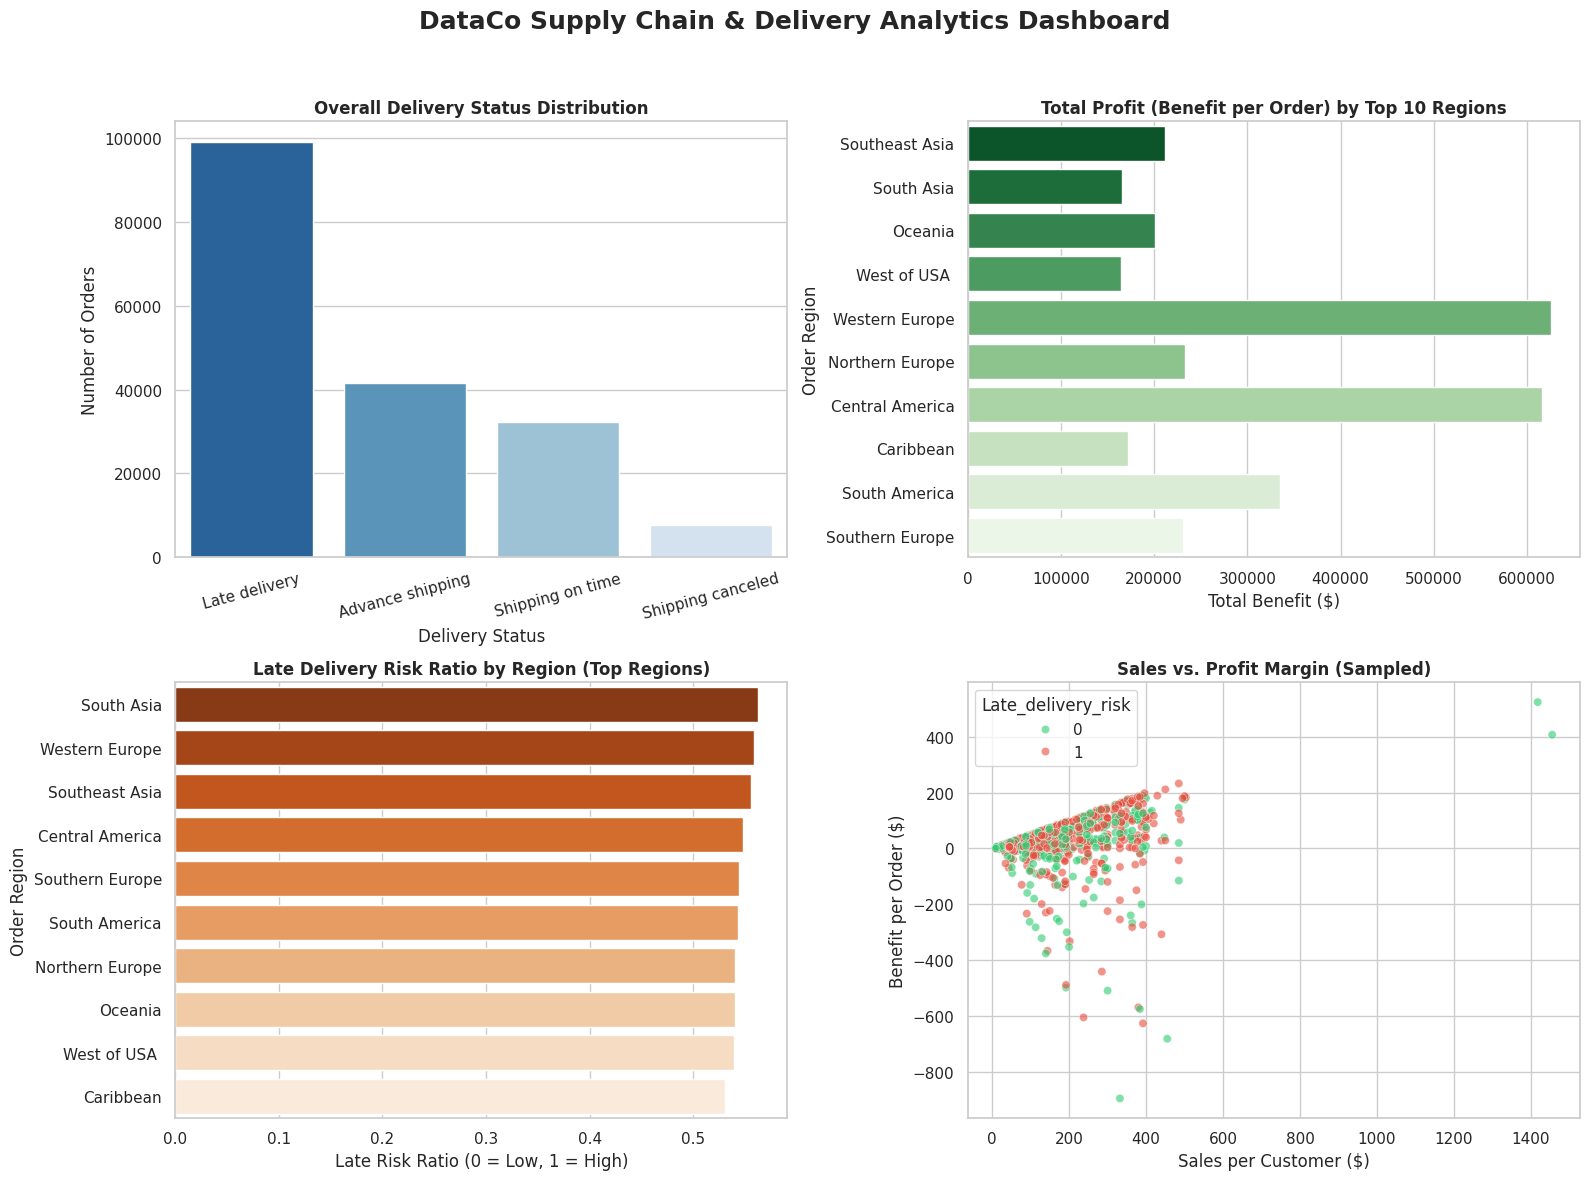

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# 1. Load Data and Clean Column Names
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.columns = df.columns.str.strip()

# Create a 2x2 subplot dashboard grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DataCo Supply Chain & Delivery Analytics Dashboard', fontsize=18, fontweight='bold', y=0.98)

# Chart 1: Distribution of Delivery Status
sns.countplot(
ax=axes[0, 0],
data=df,
x='Delivery Status',
palette='Blues_r',
order=df['Delivery Status'].value_counts().index
)
axes[0, 0].set_title('Overall Delivery Status Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Delivery Status')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=15)

# Chart 2: Profitability by Top 10 Regions
top_regions = df['Order Region'].value_counts().head(10).index
sns.barplot(
ax=axes[0, 1],
data=df[df['Order Region'].isin(top_regions)],
x='Benefit per order',
y='Order Region',
estimator=sum,
ci=None,
palette='Greens_r'
)
axes[0, 1].set_title('Total Profit (Benefit per Order) by Top 10 Regions', fontweight='bold')
axes[0, 1].set_xlabel('Total Benefit ($)')
axes[0, 1].set_ylabel('Order Region')

# Chart 3: Late Delivery Risk Rate across Top Regions
late_risk_by_region = (
df[df['Order Region'].isin(top_regions)]
.groupby('Order Region')['Late_delivery_risk']
.mean()
.reset_index()
.sort_values(by='Late_delivery_risk', ascending=False)
)

sns.barplot(
ax=axes[1, 0],
data=late_risk_by_region,
x='Late_delivery_risk',
y='Order Region',
palette='Oranges_r'
)
axes[1, 0].set_title('Late Delivery Risk Ratio by Region (Top Regions)', fontweight='bold')
axes[1, 0].set_xlabel('Late Risk Ratio (0 = Low, 1 = High)')
axes[1, 0].set_ylabel('Order Region')

# Chart 4: Sales vs. Benefit Distribution
sns.scatterplot(
ax=axes[1, 1],
data=df.sample(n=1000, random_state=42), # Sample 1,000 points for clear visual rendering
x='Sales per customer',
y='Benefit per order',
hue='Late_delivery_risk',
palette={0: '#2ecc71', 1: '#e74c3c'},
alpha=0.6
)
axes[1, 1].set_title('Sales vs. Profit Margin (Sampled)', fontweight='bold')
axes[1, 1].set_xlabel('Sales per Customer ($)')
axes[1, 1].set_ylabel('Benefit per Order ($)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()